# 10 영상 분할 및 특징 처리
영상 처리 및 컴퓨터 비전 응용에서 자주 사용되는 알고리즘을 소개한다.

# 10.1 허프 변환
직선 검출을 통해서 영상 내에서 공간 구조 분석에 유용하다. 직선 검출 방법 중에서 가장 널리 사용되는 것이 허프 변환이다. 허프변환은 영상내의 선, 원뿐만 아니라 임의의 형태를 지닌 물체를 감지해 내는 대표적인 기술로서 데이터 손실 및 왜곡이 포함된 영상에서도 직선을 잘 검출한다.

## 10.1.1 허프 변환의 좌표계
허프 변환은 영상에서 에지로 인지되는 좌표들을 직교좌표계에서 극좌표계로 변환아여 검출하고자 하는 물체의 파라미터를 추출하는 방법이다. 왜 좌표계를 변환하냐면 직교 좌표계에서는 수직선 일 때는 기울기가 무한대가 될 수 있고 검출되는 직선의 간격이 동일하지 않아서 검출 속도와 정확성에 문제가 된다.

## 10.1.2 허프 변환의 전체 과정
1. 극 좌표계에서 누적 행렬 구성
2. 영상 화소의 직선 검사
3. 직선 좌표에 대한 극좌표 누적 행렬 구성
4. 누적 행렬의 지역 최댓값 선정
5. 직선 선별 - 임계값 이상인 누적값 선택 및 정렬

## 10.1.3 직선 누적 행렬 구성
누적 행렬은 검출된 직선을 극좌표로 인덱싱해서 값을 누적하기 위한 것이다. 누적 행렬의 크기는 거리 간격과 각도 간격에 따라 조절되며, 둘의 간격이 작을수록 행렬의 크기가 커져서 해상도가 높아진다.
다음으로 직선 검사를 진행 하는데 이진화나 모폴로지와 같은 다양한 전처리로 잡음을 제거하고 직선 성분을 검출한다. 이진 영상을 입력 영상으로 사용하고 0보다 큰 화소를 직선으로 간주한다.
그리고 직교 좌표계에서 직선 상에 있던 점들은 극좌표로 가면 곡선이 된다. 그런 이유는 직교 좌표계에서 그 점을 지나는 모든 직선을 표현하기 때문이다. 그리고 직교좌표계에서 한 직선 위에 있던 점들이 극좌표에서 곡선이 되지만 모두 한 점에서 만난다. 그래서 누적 행렬을 구하면 어떤 점에서 만나는지를 알 수 있어서 직선을 검출 해낼 수 있는 것이다. 사실상 누적 행렬은 곡선을 수로 그린 것이거라고 할 수 있는 것이다.

In [5]:
import numpy as np, cv2, math
import matplotlib.pyplot as plt

In [2]:
def accumulate(img, rho, theta):
    h, w = img.shape[:2]
    rows, cols = (h+w) * 2 // rho, int(np.pi / theta)
    accumulate = np.zeros((rows, cols), np.int32)

    sin_cos = [(np.sin(t*theta), np.cos(t*theta)) for t in range(cols)]
    pts = np.where(img > 0)

    polars = np.dot(sin_cos, pts).T
    polars = (polars / rho + rows / 2).astype('int')

    for row in polars:
        for t, r in enumerate(row):
            accumulate[r, t] += 1
        
    return accumulate

## 10.1.4 누적 행렬의 지역 최댓값 선정
누적 행렬에서 누적 값이 임계값 이상인 좌표를 가져와야 하는데 비슷한 위치에 비슷한 각도로 직선들이 그려지고 다른 위치의 직선은 임계갓ㅂ 이상이여도 한 곳에서 너무 많은 직선을 검출해서 검출 순위에서 밀릴 수도 있다. 이 문제를 해결하기 위해서 마스크를 이용한다. 누적 행렬을 작은 블록으로 나누고(이를 마스크라고 한다.) 각 블록에서 가장 큰 값만 보존하고 나머지 값을 제거하는 것이다. 그리고 마스크 내에서 가장 큰 값을 지역 최댓값이라 한다.

In [3]:
def masking(accumulate, h, w, thresh):
    rows, cols = accumulate.shape[:2]
    rcenter, tcenter = h//2, w//2
    dst = np.zeros(accumulate.shape, np.uint32)

    for y in range(0, rows, h):
        for x in range(0, cols, w):
            roi = accumulate[y:y+h, x:x+w]
            _, max, _, (x0, y0) = cv2.minMaxLoc(roi)
            dst[y+y0, x+x0] = max
    
    return dst

## 10.1.5 직선(극 좌표) 선택 및 정렬
아래 함수는 중복이 제거된 누적 행렬 원소 중에서 임계값보다 큰 값을 선별해 lines 행렬에 저장한다. 긴 직선이 먼저 저장되도록 누적값을 기준으로 내림차순 정렬을 수행한다.

In [4]:
def select_lines(acc_dst, rho, theta, thresh):
    rows = acc_dst.shape[0]
    r, t = np.where(acc_dst > thresh)

    rhos = ((r - (rows / 2)) * rho)
    radians = t * theta
    values = acc_dst[r, t]

    idx = np.argsort(values)[::-1]

    lines = np.transpose([rhos, radians])
    lines = lines[idx, :]

    return np.expand_dims(lines, axis=1)

## 10.1.6 최종 완성 프로그램

In [6]:
def houghLines(src, rho, theta, thresh):
    acc_mat = accumulate(src, rho, theta)
    acc_dst = masking(acc_mat, 7, 3, thresh)
    lines = select_lines(acc_dst, rho, theta, thresh)

    return lines

def draw_houghLines(src, lines, nline):
    dst = cv2.cvtColor(src, cv2.COLOR_GRAY2BGR)
    min_length = min(len(lines), nline)

    for i in range(min_length):
        rho, radian = lines[i, 0, 0:2]
        a, b = math.cos(radian), math.sin(radian)
        pt = (a * rho, b * rho)
        delta = (-1000 * b, 1000 * a)
        pt1 = np.add(pt, delta).astype('int')
        pt2 = np.subtract(pt, delta).astype('int')
        cv2.line(dst, tuple(pt1), tuple(pt2), (0, 255, 0), 2, cv2.LINE_AA)

    return dst

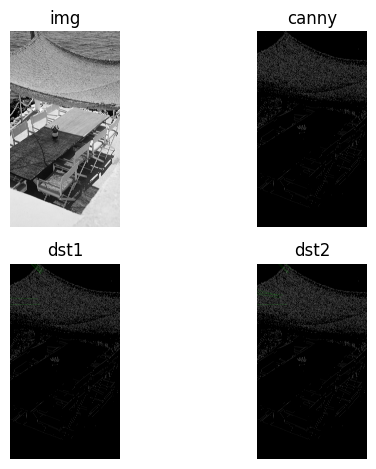

In [12]:
img = cv2.imread("../images/bench.jpg", cv2.IMREAD_GRAYSCALE)

blur = cv2.GaussianBlur(img, (5, 5), 2, 2)
canny = cv2.Canny(blur, 100, 200, 5)

rho, theta = 1, np.pi / 180
lines1 = houghLines(canny, rho, theta, 80)
lines2 = cv2.HoughLines(canny, rho, theta, 80)
dst1 = draw_houghLines(canny, lines1, 7)
dst2 = draw_houghLines(canny, lines2, 7)

titles = ['img', 'canny', 'dst1', 'dst2']
fig, axs = plt.subplots(nrows=2, ncols=2)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 10.2 코너 검출
영상에서 객체를 추적할 때나 영상과 영상을 매칭할 때 사용하는 방법은 중요한 특징 정보를 서로 비교하는 것인데 직선 정보는 영상 매칭에 도움이 되지 않는다. 그래서 다른 특징 정보로 꼭짓점 혹은 코너라고 불리는 특징점이 있다. 코너는 영상에서 경계가 만나는 지점의 특정 모양을 갖는 곳이라 한다.  
이 코너 정보 중에서 영상의 왜곡에도 불변하는 특징을 가진 지점이 영상 매칭에 유용하다. 이걸 검출하는 알고리즘을 모라벡 알고리즘이라고 한다. 이 알고리즘이 45도 간격의 에지만 고려할 수 있어서 해리스가 가우시안 마스크를 적용하여 잡음에 대한 민감도를 낮추고 코너를 모든 방향에서 검출 할 수 있도록 하였다. 그래서 영상의 평행이동 회전변환에도 불변하고 어파인, 조명 변화에도 강인성이 있지만 영상의 크기 변화에는 영향을 받는다.  
구현은 아래와 같다
1. 소벨 마스크로 미분 행렬 계산
2. 미분 행렬의 곱 계산
3. 곱 행렬에 가우시안 마스크를 적용
4. 코너 응답 함수를 계산
5. 비최대치 억제  
  
를 진행하면 되고 OpenCV 함수로 cornerHarris()로 제공되고 있다.

# 10.3 k-최근접 이웃 분류기 knn

## 10.3.1 k-최근접 이웃 분류기의 이해
최근접 이웃 알고리즘은 기존에 가지고 있는 데이터들을 일정한 규칙에 의해 분류된 상태에서 새로운 입력이 들어 왔을 때 입력 데이터의 종류를 예측하는 분류 알고리즘이다.  
종류를 예측하는 방법은 거리를 이용하는데 거리란 기존의 샘플과 새 샘플 간의 유사도가 높은 것을 가장 가까운 클래스로 지정하는데 샘플의 형태와 종류에 따라서 다양한 방식을 사용한다.  
그 중에서 가장 많이 쓰는 방법은 학습된 클래스들에서 여러 개(k개)의 가까운 이웃을 선출하고 이를 이용해 미지의 샘플을 분료하는 방법이다. 즉, 미지의 샘플과 가까운 이웃으로 선출된 여러 개의 클래스 샘플 중에서 가장 많은 수를 가진 클래스로 미지의 샘플을 분류하는 방법이다. 이 방법을 k-NN 이라고 한다.



# 10.4 영상 워핑과 영상 모핑
영상 워핑은 하나의 영상에서 비선형적인 특정한 규칙에 따라 입력 영상을 재추출하여 영상의 형태를 변형시키는 기술이다. 영상을 여러 다른 방향으로 늘이거나 크기를 조절하는 기법으로 크기 변화의 정도가 영상 전체에 균일하지 않다.  
영상 모핑은 하나의 영상에서 형체가 전혀 다른 영상으로 변하도록 하는 기법을 말한다. 워핑 기법을 이용하여 모핑을 수행한다.  
OpenCV 에서 calibrateCamera, initUndistortRectifyMap 함수 들이 워핑을 응용하는 예시이다. 